In [136]:
# data cleaning

In [137]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [138]:
# load the data

In [139]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [140]:
df.shape

(891, 15)

In [141]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

In [142]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [143]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [144]:
df.describe(include = "object")

C:\Users\yaswa\AppData\Local\Temp\ipykernel_20244\3591357663.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include = "object")


,sex,embarked,who,embark_town,alive
count,891,889,891,889,891
unique,2,3,3,3,2
top,male,S,man,Southampton,no
freq,577,644,537,644,549


In [145]:
#missing values

In [146]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [147]:
df.isnull()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [148]:
missing_percentage = (df.isnull().sum()/(len(df)))

In [149]:
missing_percentage

survived       0.000000
pclass         0.000000
sex            0.000000
age            0.198653
sibsp          0.000000
parch          0.000000
fare           0.000000
embarked       0.002245
class          0.000000
who            0.000000
adult_male     0.000000
deck           0.772166
embark_town    0.002245
alive          0.000000
alone          0.000000
dtype: float64

<Axes: >

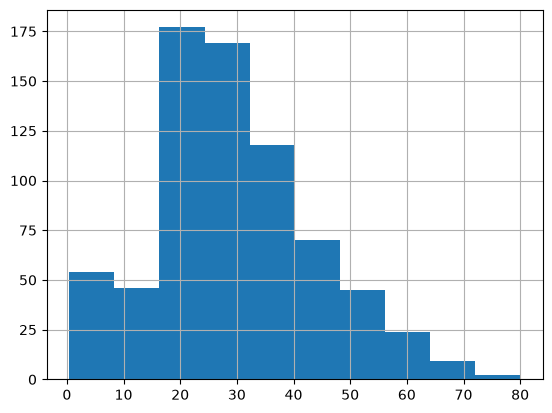

In [150]:
df["age"].hist() # we use histogram to check if the data is skewed or not

In [151]:
df["age"]=df["age"].fillna(df["age"].median())

In [152]:
df["age"]

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    28.0
889    26.0
890    32.0
Name: age, Length: 891, dtype: float64

In [153]:
missing_percentage = (df.isnull().sum()/(len(df)))
missing_percentage

survived       0.000000
pclass         0.000000
sex            0.000000
age            0.000000
sibsp          0.000000
parch          0.000000
fare           0.000000
embarked       0.002245
class          0.000000
who            0.000000
adult_male     0.000000
deck           0.772166
embark_town    0.002245
alive          0.000000
alone          0.000000
dtype: float64

In [154]:
df["embarked"]=df["embarked"].fillna(df["embarked"].mode()[0])
df["embarked"]

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: embarked, Length: 891, dtype: str

In [155]:
missing_percentage = (df.isnull().sum()/(len(df)))
missing_percentage

survived       0.000000
pclass         0.000000
sex            0.000000
age            0.000000
sibsp          0.000000
parch          0.000000
fare           0.000000
embarked       0.000000
class          0.000000
who            0.000000
adult_male     0.000000
deck           0.772166
embark_town    0.002245
alive          0.000000
alone          0.000000
dtype: float64

In [156]:
df["embark_town"]=df["embark_town"].fillna(df["embark_town"].mode()[0])
df["embark_town"]

0      Southampton
1        Cherbourg
2      Southampton
3      Southampton
4      Southampton
          ...     
886    Southampton
887    Southampton
888    Southampton
889      Cherbourg
890     Queenstown
Name: embark_town, Length: 891, dtype: str

In [157]:
del df["deck"]

In [158]:
missing_percentage = (df.isnull().sum()/(len(df)))
missing_percentage

survived       0.0
pclass         0.0
sex            0.0
age            0.0
sibsp          0.0
parch          0.0
fare           0.0
embarked       0.0
class          0.0
who            0.0
adult_male     0.0
embark_town    0.0
alive          0.0
alone          0.0
dtype: float64

In [159]:
df.duplicated().sum()

np.int64(116)

In [ ]:
df.head()

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

In [ ]:
## data type cleaning

In [164]:
df.head()

In [165]:
df.dtypes

survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
embark_town         str
alive               str
alone              bool
dtype: object

In [166]:
df["adult_male"]=df["adult_male"].astype(int)

In [167]:
df["alone"]=df["alone"].astype(int)

In [168]:
df["sex"].unique()

<StringArray>
['male', 'female']
Length: 2, dtype: str

In [169]:
df["sex"] = df["sex"].str.lower()

In [170]:
df["embark_town"]=df["embark_town"].str.strip()

In [171]:
# boxplot

<Axes: ylabel='fare'>

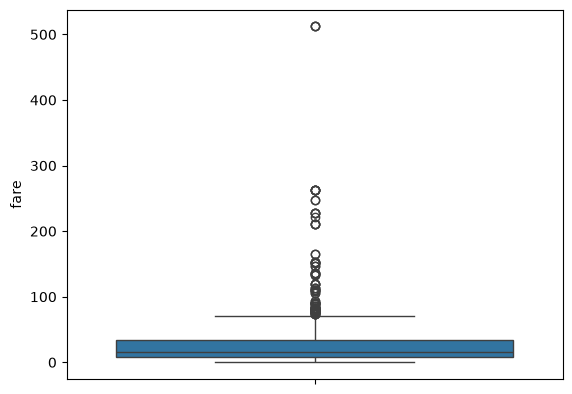

In [172]:
sns.boxplot(df["fare"])

In [173]:
Q1 =df["fare"].quantile(0.25)
Q3 = df["fare"].quantile(0.75)

IQR = Q3 -Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [174]:
# IDENTIFY THE OUTLIERS

In [175]:
outliers = df[(df["fare"]<lower) | (df["fare"]>upper)]

In [176]:
outliers

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
27,0,1,male,19.0,3,2,263.0000,S,First,man,1,Southampton,no,0
31,1,1,female,28.0,1,0,146.5208,C,First,woman,0,Cherbourg,yes,0
34,0,1,male,28.0,1,0,82.1708,C,First,man,1,Cherbourg,no,0
52,1,1,female,49.0,1,0,76.7292,C,First,woman,0,Cherbourg,yes,0
61,1,1,female,38.0,0,0,80.0000,S,First,woman,0,Southampton,yes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
829,1,1,female,62.0,0,0,80.0000,S,First,woman,0,Southampton,yes,1
835,1,1,female,39.0,1,1,83.1583,C,First,woman,0,Cherbourg,yes,0
849,1,1,female,28.0,1,0,89.1042,C,First,woman,0,Cherbourg,yes,0
856,1,1,female,45.0,1,1,164.8667,S,First,woman,0,Southampton,yes,0


In [177]:
## remove outliers

In [178]:
df = df[(df["fare"]>=lower)&(df["fare"]<=upper)]

<Axes: ylabel='fare'>

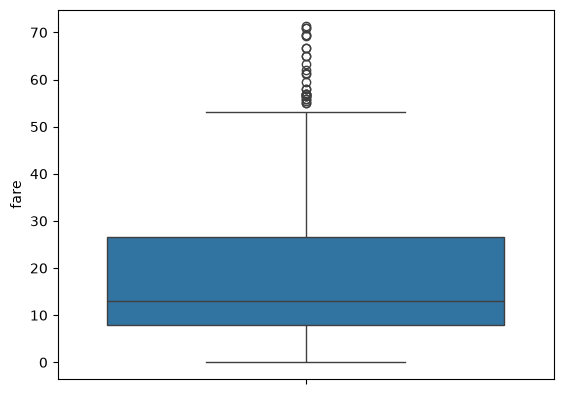

In [179]:
sns.boxplot(df["fare"])

In [180]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,1,Southampton,no,0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,0,Cherbourg,yes,0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,0,Southampton,yes,1
3,1,1,female,35.0,1,0,53.1000,S,First,woman,0,Southampton,yes,0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,1,Southampton,no,1


In [183]:
df["survived"].value_counts()

survived
0    427
1    246
Name: count, dtype: int64

In [184]:
df["pclass"].value_counts()

pclass
3    401
2    159
1    113
Name: count, dtype: int64

In [185]:
# final validation

In [187]:
df.isnull().sum()
df.dtypes
df.shape
df.describe()

,survived,pclass,age,sibsp,parch,fare,adult_male,alone
count,673.000000,673.000000,673.000000,673.000000,673.000000,673.000000,673.000000,673.000000
mean,0.365527,2.427935,28.950223,0.509658,0.396731,19.496087,0.603269,0.601783
std,0.481936,0.762549,13.604993,1.022214,0.837258,14.809501,0.489583,0.489895
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,21.000000,0.000000,0.000000,7.895800,0.000000,0.000000
50%,0.000000,3.000000,28.000000,0.000000,0.000000,13.000000,1.000000,1.000000
75%,1.000000,3.000000,36.000000,1.000000,0.000000,26.550000,1.000000,1.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,71.283300,1.000000,1.000000


In [188]:
# save data to new file

In [189]:
df.to_csv("titanic_data_cleaned" , index = False)

In [190]:
## reusable data quality report function

In [192]:
def data_quality_report(df):
    report={
        "shape" : df.shape,
        "missing_values" :df.isnull().sum(),
        "duplicate_count": int(df.duplicated().sum()),
        "data_type" : df.dtype.astype(str).to.dict()
    }